# 10 - Generative priors for score-based DA

Three generative priors replace the Gaussian background of 3DVar, all scored on the
same two lanes and the same tidy schema notebook 09 compares.

**`generative`** - an unconditional diffusion model over the full `(2, 32, 64)` anomaly
field. Reconstruction is guided posterior sampling: the EDM reverse process plus an
observation-guidance score `grad log p(y | x_sigma)` from the Gaussian likelihood
`N(y; H x_hat, S(sigma))`, with `x_hat = D(x_sigma; sigma)` and

    S(sigma) = gamma * H Sigma(sigma) H^T + R,

the annealed tapered background covariance at the observed cells: `Sigma(sigma)`
shrinks each eigenvalue `lam` of B to `lam sigma^2 / (lam + sigma^2)`, so S runs from
`gamma * H B H^T + R`, the 3DVar innovation covariance, at high noise down to `R` as
`sigma -> 0`, and clustered sites share their evidence instead of counting as
independent (Manshausen et al. 2025; Rozet and Louppe 2023; Chung et al. 2023; Boys et
al. 2023).

**`generative_hybrid`** anchors the score's Gaussian part to the tapered B: at or above
a switch noise level the denoiser is the closed-form Gaussian denoiser of
`N(0, amp * B)` (the net is essentially untrained there), below it the trained net, and
the guidance shares the same amp-scaled covariance. `(amp, sigma_switch, gamma)` are
tuned jointly on the selection split.

**`generative_spectral`** confines the learned prior to the leading eigen-directions of
B, whitened, and keeps the orthogonal complement exactly Gaussian. It is described in
its own section below; the short version is that it imposes the mean and covariance by
construction and spends its capacity only where the LOVECLIM states are actually
non-Gaussian.

**Run notebook 07 first.** The background this notebook guides with, and the band-pass
window its training frame uses, are both read out of `outputs/da/3dvar_pixel/`, so every
method here weighs observations with the covariance its own baseline was tuned on. The
band-pass moves the training frame, so `RETRAIN` and `SPECTRAL_RETRAIN` are on: both
checkpoints are rebuilt. They can go back to `False` afterwards, since each checkpoint now
records its window and is retrained automatically if the frame moves again.

`LANES`, `HYBRID_LANES` and `SPECTRAL_LANES` select which methods run and on which
lanes, independently. They are set to the PPE lane for `generative` and
`generative_spectral`, and off for `generative_hybrid`. Each writes to its own directory
under `outputs/da/`.

In [1]:
%load_ext autoreload
%autoreload 2

import json
import os
for _v in ("OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS",
           "NUMEXPR_NUM_THREADS", "VECLIB_MAXIMUM_THREADS"):
    os.environ[_v] = "1"

import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

sys.path.insert(0, os.path.abspath(".."))

from paleoreco.data import build_prior_cube, VARS
from paleoreco.data.cube import apply_anomaly, compute_zscore_stats, highpass_states
from paleoreco.data.splits import chronological_half_split
from paleoreco.assim.observations import (
    attach_site_stats, collapse_to_samples, load_observations, observation_site_stats,
)
from paleoreco.models.diffusion import CircularUNet, EDMDenoiser, load_denoiser, SIGMA_DATA
from paleoreco.models.spectral_score import build_spectral_denoiser, load_spectral_denoiser
from paleoreco.training import trainer_diffusion as td
from paleoreco.assim.generative import (
    GuidedSampler, HybridDenoiser, cell_scales, guidance_cov,
)
from paleoreco.assim.spectral import (
    SpectralSampler, build_spectral_basis, match_subspace_covariance,
)
from paleoreco.assim.priors import build_prior
from paleoreco.assim.sampler_pool import SamplerPool
from paleoreco.assim import experiments_generative as gex
from paleoreco.eval import da

plt.rcParams["figure.dpi"] = 110
DATA = "../data"
OUT = Path("../outputs/da")
CKPT = Path("../outputs/checkpoints/10_generative_prior")
FIG = Path("../outputs/figures/10_generative_prior")
CKPT.mkdir(parents=True, exist_ok=True)
FIG.mkdir(parents=True, exist_ok=True)

DEVICE = ("cuda" if torch.cuda.is_available()
          else "mps" if torch.backends.mps.is_available() else "cpu")

# Which lanes each method runs, as a subset of ("ppe", "withholding"). The three are
# independent, so a run can do one method, several, or none; the frames to build
# follow from the union. Only the two pixel-space methods need the U-Net checkpoint,
# so their priors are tracked separately from the frames.
LANES = ("ppe", )                       # generative: pixel-space score prior
HYBRID_LANES = ()                       # generative_hybrid: B-anchored above the switch
SPECTRAL_LANES = ("ppe", )              # generative_spectral: whitened eigen-subspace
# Build the pixel samplers for these lanes without re-running them. The comparison
# figures below draw fresh samples, so a method needs a live sampler to appear as a
# column even when its lane finished on an earlier run; set this to ("ppe",) to put
# the pixel priors alongside the spectral one in the PC-marginal figures.
PIXEL_SAMPLERS_FOR = ()
TRUTH_STRIDE = 10                       # ppe lane
FOLD_KIND, AGE_STRIDE = "random", 6     # withholding lane

LANE_PRIOR = {"ppe": "chunkA", "withholding": "full"}
LANE_NAME = {"ppe": "ppe", "withholding": f"withholding_{FOLD_KIND}"}

# Background covariance per lane: the config notebook 07's grid selected for that lane,
# so every method weighs observations with the covariance its own baseline trusts. The
# pixel methods build their guidance from it; the spectral method eigen-splits it.
# Reading it back rather than hard-coding it matters now that the grid has a fourth
# knob: re-running 07 can move the whole config, and a stale copy here would quietly
# guide with a covariance no baseline uses.
_TAPER_FALLBACK = {
    "ppe": dict(localization_km=15000.0, shrinkage_lambda=0.0, alpha=0.25,
                highpass_window=None),
    "withholding": dict(localization_km=None, shrinkage_lambda=0.5, alpha=0.5,
                        highpass_window=None),
}


def selected_taper(lane):
    """Notebook 07's selected pixel config for ``lane``, or the last known one."""
    path = OUT / "3dvar_pixel" / f"{LANE_NAME[lane]}_config.json"
    if not path.exists():
        print(f"[{lane}] no {path.name} from notebook 07; falling back to "
              f"{_TAPER_FALLBACK[lane]}")
        return dict(_TAPER_FALLBACK[lane])
    sel = json.load(open(path))["selected"]
    return {k: sel.get(k, _TAPER_FALLBACK[lane][k])
            for k in ("localization_km", "shrinkage_lambda", "alpha", "highpass_window")}


GUIDANCE_TAPER = {lane: selected_taper(lane) for lane in ("ppe", "withholding")}
# The band-pass is a property of the prior states, so it also decides the frame the
# diffusion model is trained in, not just the guidance covariance. One window per
# prior; LANE_PRIOR is a bijection, so this is well defined.
HIGHPASS = {LANE_PRIOR[lane]: t["highpass_window"] for lane, t in GUIDANCE_TAPER.items()}

# --- generative_spectral -------------------------------------------------------
# k is the subspace dimension. Held-out mixture experiments on this lane put the
# optimum near 8: every k from 5 to 16 gained from a non-Gaussian prior, k=8 most,
# and k=16 collapses because 402 states cannot support a 16-dim density. Changing it
# changes the basis and therefore the trained model, so a k sweep is a re-run into a
# separate directory rather than a knob the runner sweeps.
SPECTRAL_K = 8
# Rescale the training states so their covariance in the retained subspace equals B's
# leading block. Without it the model learns the *empirical* variance of those
# directions, which differs from the tuned B by factors of 0.19 to 1.9, and so quietly
# undoes the localisation and cross-channel taper exactly where they carry the most
# weight - measured at -0.053 CE. The rescale is an invertible linear map, so the
# learned skew, kurtosis and bimodality pass through it untouched; this restores the
# second moment, it does not impose Gaussianity. False reproduces the earlier
# behaviour, archived as generative_spectral_rawcov.
SPECTRAL_MATCH_COVARIANCE = True
SPECTRAL_B_SCALES = (0.5, 1.0, 2.0, 5.0)     # the same amplitude 3DVar tunes
SPECTRAL_K_SAMPLES, SPECTRAL_K_SELECT = 256, 64
SPECTRAL_STEPS, SPECTRAL_MAX_BATCH, SPECTRAL_N_PRIOR_VAR = 64, 256, 512
SPECTRAL_WIDTH, SPECTRAL_DEPTH = 256, 3
SPECTRAL_EPOCHS, SPECTRAL_PATIENCE, SPECTRAL_BATCH, SPECTRAL_LR = 4000, 200, 64, 2e-3
SPECTRAL_VAL_FRACTION, SPECTRAL_SPLIT_SEED = 0.25, 0
# True for the band-pass re-run: the basis is rebuilt from a different B, so the
# archived checkpoint belongs to another frame. The provenance check below catches that
# on its own, so this can go back to False once the checkpoint has been rewritten.
SPECTRAL_RETRAIN = True
# Train on the CPU regardless of DEVICE: the model is a few-layer MLP over k
# dimensions, so kernel-launch overhead dominates and a GPU measures about 4x
# slower per epoch than the CPU here (96 ms against 22 ms). Sampling is on the
# CPU for the same reason.
# How the likelihood is annealed. "anchor" uses the Gaussian anchor's conditional
# covariance, a scalar times the identity, which is exact only where the prior is
# Gaussian and so mis-weights the update exactly where the learned bimodality is.
# "jacobian" uses the model's own, sigma^2 grad D by second-order Tweedie, exact
# for whatever the network learned and reducing to "anchor" when its output is
# zero. Affordable only because the Jacobian is k x k. "anchor" reproduces the
# arm archived as generative_spectral_anchorguid.
SPECTRAL_COND_COV = "jacobian"
SPECTRAL_DEVICE = "cpu"

PRIORS_PIXEL = sorted({LANE_PRIOR[lane]
                       for lane in (*LANES, *HYBRID_LANES, *PIXEL_SAMPLERS_FOR)})
PRIORS = sorted({LANE_PRIOR[lane]
                 for lane in (*LANES, *HYBRID_LANES, *SPECTRAL_LANES,
                              *PIXEL_SAMPLERS_FOR)})
print("device:", DEVICE, "| lanes:", LANES, "| hybrid:", HYBRID_LANES,
      "| spectral:", SPECTRAL_LANES)
print("priors:", PRIORS, "| of which pixel-space:", PRIORS_PIXEL)
for _lane, _t in GUIDANCE_TAPER.items():
    print(f"  {_lane:12s} background config {_t}")

/vol/bitbucket/egg25/diss/sparse_paleoclimate_field_reconstruction/paleo/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[withholding] no withholding_random_config.json from notebook 07; falling back to {'localization_km': None, 'shrinkage_lambda': 0.5, 'alpha': 0.5, 'highpass_window': None}
device: cuda | lanes: ('ppe',) | hybrid: () | spectral: ('ppe',)
priors: ['chunkA'] | of which pixel-space: ['chunkA']
  ppe          background config {'localization_km': 15000.0, 'shrinkage_lambda': 0.0, 'alpha': 0.5, 'highpass_window': 6000.0}
  withholding  background config {'localization_km': None, 'shrinkage_lambda': 0.5, 'alpha': 0.5, 'highpass_window': None}


## Prior cube, chronological split, and the normalised anomaly frames

Each frame is the per-cell anomaly over its own ages, band-passed along the age axis and
then rescaled **per cell** to std `SIGMA_DATA`, the scale the EDM recipe expects. The
states, the climatology and the scale field all come from those ages, so the PPE prior
never sees the younger truths.

**The band-pass, and why it is applied here.** Notebook 07 selects a `highpass_window` per
lane; a running mean of that width is removed from each state before anything else. The
prior half is a ten-thousand-year stretch of a transient run, and its slow component
belongs to that stretch rather than to the climate: on the PPE lane the older half's
second principal component is 79% a multi-millennial trend that does not describe the
younger half at all. Removing it is worth about +0.04 CE to the 3DVar baseline, and every
method here inherits it.

It has to happen at the frame rather than only inside `build_prior`, because the scale
field and the normalised cube are both derived from these states. Filtering B alone would
train the denoiser on unfiltered states and then guide it with a filtered covariance,
the same frame mismatch the spectral section below was built to remove. Both checkpoints
now carry their window, so a model from the other frame is retrained rather than silently
reused.

Scaling per cell rather than per channel leaves unit variance everywhere, so the
network learns correlation structure and the spatial variance pattern is carried by
the scale field instead. Two consequences follow and are worth holding in view when
reading the results below. The prior's variance geography is imposed rather than
learned, so its marginal per-cell variances come from the same empirical source
`diag(B)` does. And the network spends equal capacity on climatically inert cells and
on the North Atlantic centre carrying the D-O signal, which may cost skill even where
it helps calibration.

In [2]:
P = build_prior_cube(prior_csv=f"{DATA}/Prior.csv", cache_path=f"{DATA}/cache/prior_cube.npz")
cube, ages, lats, lons, valid = P["cube"], P["ages"], P["lats"], P["lons"], P["valid"]

all_idx = np.arange(len(ages))
prior_idx, truth_idx = chronological_half_split(ages, stride=TRUTH_STRIDE)
PRIOR_IDX = {"chunkA": prior_idx, "full": all_idx}

long_ppe = load_observations(f"{DATA}/Observation.csv")
long_wh = attach_site_stats(long_ppe, observation_site_stats(collapse_to_samples(long_ppe)))


def frame(idx, highpass_window):
    """safe_valid mask, per-cell scale field, and the SIGMA_DATA-scaled anomaly cube over ``idx``.

    The cube is restricted to ``idx`` after centring, so the states, the climatology
    and the scale field all come from the same ages.

    ``highpass_window`` removes a running mean along the age axis from those states, so
    the model is trained on the same fast component the lane's background covariance
    describes. It has to be applied here rather than only to B: the scale field and the
    normalised cube are derived from these states, and a model trained on unfiltered
    states guided by a filtered covariance would be the frame mismatch this whole
    notebook is trying to avoid.
    """
    stats = compute_zscore_stats(cube, idx, valid)
    anom = apply_anomaly(cube, stats)[idx]
    anom = highpass_states(anom, np.asarray(ages)[idx], highpass_window)
    scales = cell_scales(anom, stats["safe_valid"])
    norm = anom * (SIGMA_DATA / scales)
    return stats["safe_valid"], scales, anom.astype(np.float64), norm.astype(np.float32)


FRAME = {name: frame(PRIOR_IDX[name], HIGHPASS[name]) for name in PRIORS}
print("cube", cube.shape, "| sites", long_ppe["site"].nunique())
for name, (safe, scales, _, norm) in FRAME.items():
    print(f"{name}: {norm.shape[0]} states | band-pass {HIGHPASS[name]} | per-cell scale "
          f"{scales[:, safe].min():.3f} to {scales[:, safe].max():.3f} degC "
          f"| normalised per-cell std {norm[:, :, safe].std(axis=0).mean():.3f} "
          f"(target {SIGMA_DATA})")

cube (804, 2, 32, 64) | sites 187
chunkA: 402 states | band-pass 6000.0 | per-cell scale 0.044 to 6.853 degC | normalised per-cell std 0.500 (target 0.5)


## Train the diffusion priors

Small U-Net, EDM denoising-score-matching with EMA. Data is scarce (hundreds of
autocorrelated states), so the epoch count is selected rather than fixed: each prior
first *searches* on a random 75/25 split, stopping once the held-out score has not
improved for `PATIENCE` epochs, then *refits* on every state up to the best epoch.

The held-out score is the EDM loss on a fixed grid of noise levels with fixed noise,
not the training loss: the training loss draws a random noise level per sample, and
that spread is far larger than the epoch-to-epoch change early stopping has to
resolve. It scores the EMA weights, since those are what the checkpoint saves and
the sampler loads.

The refit keeps the cosine horizon at `EPOCHS`, so it follows the same learning-rate
trajectory the search selected on and the chosen epoch keeps its meaning. Set
`RETRAIN = False` once the checkpoints exist to skip both phases; a checkpoint left
over from a different scale frame is retrained regardless, since its weights are not
usable in this one.

In [3]:
# True for the band-pass re-run: the training states have moved, so every archived
# checkpoint belongs to another frame. _frame_matches below now detects that on its own,
# so this can go back to False once the checkpoints have been rewritten.
RETRAIN = True
EPOCHS, BASE, DEPTH, LR, BATCH = 3000, 64, 2, 2e-4, 64
VAL_FRACTION, PATIENCE, SPLIT_SEED = 0.25, 50, 0
T0 = time.time()


def _net():
    return EDMDenoiser(CircularUNet(base_channels=BASE, depth=DEPTH,
                                    grid_shape=tuple(cube.shape[2:])))


def checkpoint_path(name):
    return CKPT / f"diffusion_{name}.pt"


def _frame_matches(path, shape, highpass_window):
    """Whether a checkpoint was trained in the scale frame about to be used.

    A checkpoint from a different frame would otherwise be kept and then fail when
    the sampler loads it, so a stale one is retrained rather than skipped.

    The band-pass has to be checked by name, not by shape: filtering the states changes
    every value in the scale field but none of its dimensions, so a checkpoint from the
    unfiltered frame would pass a shape test and then be sampled in the wrong frame
    without complaint. Checkpoints written before the knob existed carry no window and
    read as unfiltered, which is what they are.
    """
    try:
        ck = torch.load(path, map_location="cpu")
    except Exception:
        return False
    return (np.shape(ck.get("scales")) == shape
            and ck.get("highpass_window", -1.0) == (-1.0 if highpass_window is None
                                                    else float(highpass_window)))


def train_prior(name):
    """Select the epoch count on a held-out split, then refit on every state."""
    safe, scales, _, norm = FRAME[name]
    path = checkpoint_path(name)
    hp = HIGHPASS[name]
    if path.exists() and not RETRAIN and _frame_matches(path, scales.shape, hp):
        print("exists:", path.name)
        return None

    perm = np.random.default_rng(SPLIT_SEED).permutation(len(norm))
    n_val = int(round(VAL_FRACTION * len(norm)))
    val_idx, train_idx = perm[:n_val], perm[n_val:]

    print(f"[{name}] search | {len(train_idx)} train / {len(val_idx)} val "
          f"| band-pass {hp} | max {EPOCHS} ep, patience {PATIENCE}", flush=True)
    t = time.time()
    search = td.train(_net(), norm[train_idx], safe, val_cube=norm[val_idx],
                      patience=PATIENCE, max_epochs=EPOCHS, batch_size=BATCH,
                      lr=LR, device=DEVICE, seed=0)
    n_star = search["best_epoch"] + 1          # 0-based index -> epoch count
    print(f"[{name}] search | done in {time.time() - t:.0f}s "
          f"| best ep {search['best_epoch']} | stopped at {search['stop_epoch']} "
          f"| early={search['stopped_early']} | refit to {n_star}", flush=True)

    print(f"[{name}] refit | {n_star} ep on {len(norm)} states", flush=True)
    t = time.time()
    td.train(_net(), norm, safe, max_epochs=n_star, lr_schedule_epochs=EPOCHS,
             batch_size=BATCH, lr=LR, device=DEVICE, checkpoint_path=str(path),
             scales=scales, seed=0,
             checkpoint_extra={
                 # -1 stands for "no band-pass": checkpoint_extra takes plain scalars
                 # only, so it cannot carry None and stay loadable under weights_only.
                 "highpass_window": -1.0 if hp is None else float(hp),
                 "selection": {
                     "best_epoch": int(search["best_epoch"]),
                     "stop_epoch": int(search["stop_epoch"]),
                     "refit_epochs": int(n_star),
                     "stopped_early": bool(search["stopped_early"]),
                     "patience": int(PATIENCE), "val_fraction": float(VAL_FRACTION),
                     "split_seed": int(SPLIT_SEED), "max_epochs": int(EPOCHS)}})
    print(f"[{name}] refit | done in {time.time() - t:.0f}s | wrote {path.name}", flush=True)

    np.savez(CKPT / f"{path.stem}_search.npz",
             **{k: np.asarray(v) for k, v in search["history"].items()})
    return search


SEARCH = {name: train_prior(name) for name in PRIORS_PIXEL}
print(f"total {time.time() - T0:.0f}s")

[chunkA] search | 302 train / 100 val | band-pass 6000.0 | max 3000 ep, patience 50


diffusion:   0%|                                       | 0/3000 [00:00<?, ?ep/s]

diffusion:   0%| | 0/3000 [00:17<?, ?ep/s, loss=0.9778, val=0.8621, best=0.8621,

diffusion:   0%| | 1/3000 [00:17<14:33:29, 17.48s/ep, loss=0.9778, val=0.8621, b

epoch    0  loss=0.9778  val=0.8621  best=0.8621@0  lr=2.00e-04  (17.5s)


...

diffusion: 100%|██████▉| 990/991 [04:08<00:00,  4.00ep/s, loss=0.1485, s/ep=0.2]

diffusion: 100%|███████| 991/991 [04:08<00:00,  3.99ep/s, loss=0.1566, s/ep=0.3]

diffusion: 100%|███████| 991/991 [04:08<00:00,  3.98ep/s, loss=0.1566, s/ep=0.3]

[chunkA] refit | done in 249s | wrote diffusion_chunkA.pt


total 863s


### Search curves

Red marks where early stopping halted the search, grey the best epoch the refit used.
On the left all three curves are the same fixed-grid score, so the gap between the
training probe and the held-out curve is the generalisation gap, and the gap between
the EMA and live curves is the lag introduced by weight averaging. The right panel is
the random-sigma quantity actually minimised, which sits on its own scale.

If the probe and held-out curves sit on top of each other and never separate, the
random split has no detection power on states this autocorrelated, and the result is
inconclusive rather than evidence of no overfitting.

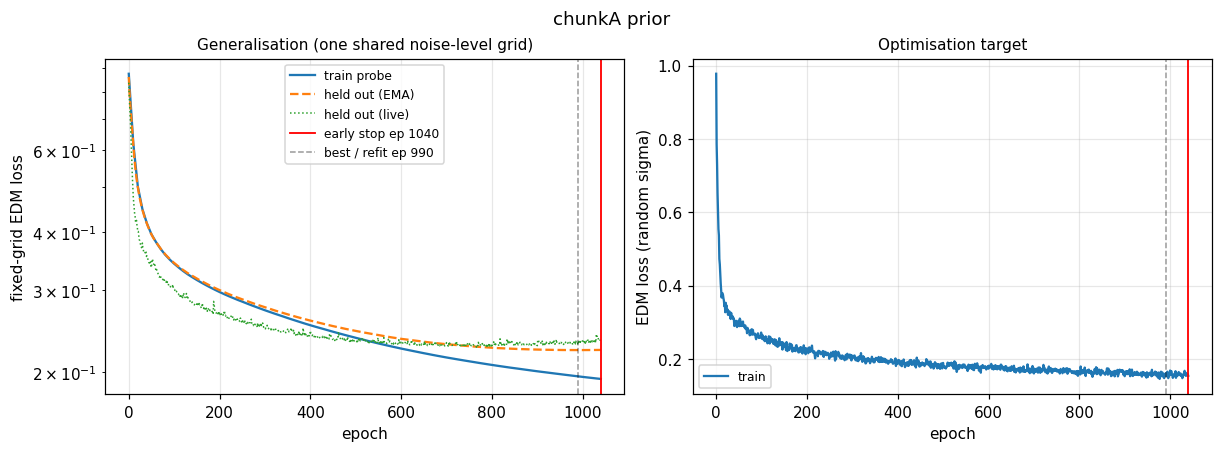

In [4]:
from paleoreco.eval.diffusion import plot_loss_curves_diffusion

for name, search in SEARCH.items():
    if search is None:
        continue
    plot_loss_curves_diffusion(
        search["history"], best_epoch=search["best_epoch"],
        stop_epoch=search["stop_epoch"] - 1, title=f"{name} prior",
        save_path=str(FIG / f"loss_curves_{name}.png"))
    plt.show()

## Build the samplers

One sampler per trained prior for the diagnostics below. The lanes themselves run on
a `SamplerPool`, built and closed around each lane: a single posterior draw occupies
a fraction of the GPU, so spreading independent draws over `N_WORKERS` processes is
most of the run's wall clock. Every draw carries its own seed, so the pooled result
is the serial one.

Each sampler and pool takes a guidance covariance: the lane's tapered background
covariance, moved into the checkpoint's per-cell frame and eigendecomposed once
(`guidance_cov`). The taper is the lane's 3DVar-selected config, so the guidance
weighs observations with the covariance the baseline trusts, and the PPE lane's
covariance never sees the younger truths. `PRIOR_VAR`, the per-cell variance of
unconditional draws, remains as a diagnostic: the analysis npz and the spread
figures read it, the likelihood does not.

Ensemble sizes are asymmetric. Below about 16 members a draw costs what one member
costs, so `K_SELECT` is free; the reported `K` is larger because averaging a finite
ensemble inflates the error by `mean(post_var) / K`, and 3DVar carries no such term.

In [5]:
N_STEPS = 64
GAMMA_GRID = gex.GAMMA_GRID
AMP_GRID, SWITCH_GRID = gex.AMP_GRID, gex.SWITCH_GRID
HYBRID_GAMMA_GRID = gex.HYBRID_GAMMA_GRID
K, K_SELECT = 256, 16
N_WORKERS = 1
N_PRIOR_VAR = 512
# max_batch: a K=256 guided draw in one batch peaks near 4 GiB on the shared
# card (the guidance backward pass stores activations for the whole batch);
# chunks of 64 draw the same i.i.d. ensemble within ~1.5 GiB, and peak memory falls
# roughly linearly from there. Set to 16 (~0.4 GiB) because the card is currently
# carrying another user's 14.5 GiB job: chunking is distributionally exact, so this
# costs a little launch overhead and nothing else.
MAX_BATCH = 16
SAMPLER_KW = dict(n_samples=K, n_steps=N_STEPS, max_batch=MAX_BATCH, device=DEVICE)


def load_sampler(name, cov):
    net, scales = load_denoiser(str(checkpoint_path(name)))
    return GuidedSampler(net, np.asarray(scales), FRAME[name][0], cov, **SAMPLER_KW)


# One guidance covariance per lane prior, in that checkpoint's own frame. The eigh
# runs single-threaded (BLAS threads are pinned above) and costs about a minute.
COV = {}
for lane in sorted(set(LANES) | set(HYBRID_LANES) | set(PIXEL_SAMPLERS_FOR)):
    name = LANE_PRIOR[lane]
    prior_b = build_prior(cube, ages, lats, lons, PRIOR_IDX[name], valid,
                          **GUIDANCE_TAPER[lane])
    COV[name] = guidance_cov(prior_b.B, FRAME[name][1], FRAME[name][0],
                             meta={"prior": name, **prior_b.meta})

SAMPLER = {name: load_sampler(name, COV[name]) for name in PRIORS_PIXEL}


def prior_var_map(name, n=N_PRIOR_VAR, seed=0):
    """Per-cell prior variance from ``n`` unconditional draws, anomaly units.

    Diagnostic only: the analysis npz and the spread figures read it, the guidance
    reads COV. Batched because an ensemble this size does not fit in one forward
    pass.
    """
    s = SAMPLER[name]
    ens = np.concatenate([s.sample_prior(64, seed=seed + k) for k in range(n // 64)])
    return ens.var(axis=0, ddof=1)


PRIOR_VAR = {name: prior_var_map(name) for name in PRIORS_PIXEL}

for name in PRIORS_PIXEL:
    safe, scales, _, _ = FRAME[name]
    pv = PRIOR_VAR[name][:, safe]
    print(f"{name}: prior std {np.sqrt(pv).mean():.3f} degC against a scale field of "
          f"{scales[:, safe].mean():.3f} | corr "
          f"{np.corrcoef(np.sqrt(pv).ravel(), scales[:, safe].ravel())[0, 1]:.3f}")

chunkA: prior std 0.696 degC against a scale field of 0.738 | corr 0.999


## Unconditional sanity: did the prior learn the climate?

Given the small training set, check that generated fields resemble real LOVECLIM
states (per-cell std, leading-PC score spread) and that the model is not
regurgitating training snapshots (nearest-neighbour distance).

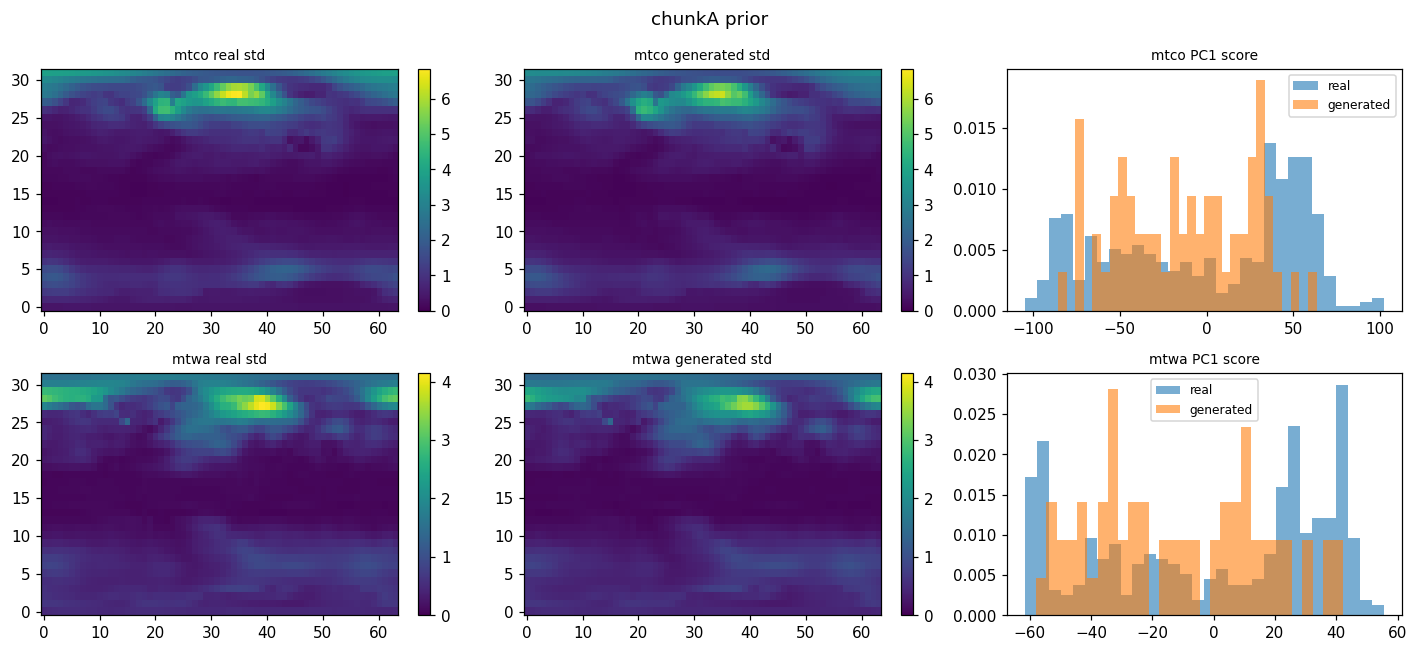

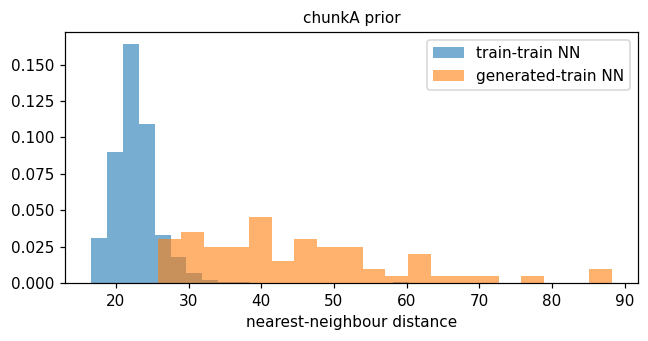

chunkA: median NN distance generated 41.465 | train 22.287


In [6]:
from scipy.spatial.distance import cdist

for name in PRIORS_PIXEL:
    safe, _, anom, _ = FRAME[name]
    real = anom[:, :, safe]
    gen = SAMPLER[name].sample_prior(64, seed=0)[:, :, safe]

    fig, axes = plt.subplots(2, 3, figsize=(13, 6))
    for c, ch in enumerate(VARS):
        vmax = float(real[:, c].std(0).max())
        for col, (title, field) in enumerate((("real std", real[:, c].std(0)),
                                              ("generated std", gen[:, c].std(0)))):
            m = np.full(safe.shape, np.nan); m[safe] = field
            ax = axes[c, col]
            im = ax.imshow(m, origin="lower", cmap="viridis", vmin=0, vmax=vmax,
                           aspect="auto")
            ax.set_title(f"{ch} {title}", fontsize=9)
            fig.colorbar(im, ax=ax, fraction=0.046)
        # leading-PC score distribution, generated vs real
        Xr = real[:, c] - real[:, c].mean(0)
        pc = np.linalg.svd(Xr, full_matrices=False)[2][0]
        axes[c, 2].hist(Xr @ pc, bins=30, density=True, alpha=0.6, label="real")
        axes[c, 2].hist((gen[:, c] - real[:, c].mean(0)) @ pc, bins=30, density=True,
                        alpha=0.6, label="generated")
        axes[c, 2].set_title(f"{ch} PC1 score", fontsize=9)
        axes[c, 2].legend(fontsize=8)
    fig.suptitle(f"{name} prior")
    fig.tight_layout()
    fig.savefig(FIG / f"unconditional_quality_{name}.png", bbox_inches="tight")
    plt.show()

    # Memorisation: nearest training state per generated sample against a train-train
    # baseline. cdist avoids the O(N^2 D) broadcast that would materialise tens of GB.
    gv, rv = gen.reshape(len(gen), -1), real.reshape(len(real), -1)
    d_gen = cdist(gv, rv).min(1)
    dd = cdist(rv, rv); np.fill_diagonal(dd, np.inf)
    d_train = dd.min(1)
    fig, ax = plt.subplots(figsize=(6, 3.2))
    ax.hist(d_train, bins=20, density=True, alpha=0.6, label="train-train NN")
    ax.hist(d_gen, bins=20, density=True, alpha=0.6, label="generated-train NN")
    ax.set_xlabel("nearest-neighbour distance"); ax.legend()
    ax.set_title(f"{name} prior", fontsize=10)
    fig.tight_layout(); fig.savefig(FIG / f"memorisation_{name}.png", bbox_inches="tight")
    plt.show()
    print(f"{name}: median NN distance generated {np.median(d_gen):.3f} "
          f"| train {np.median(d_train):.3f}")

## Run the generative lanes

PPE on the older-half prior, withholding on the all-ages prior, whichever `LANES`
selects. `gamma` is swept on the selection split and reported at its winner on the
test split; withholding is age-subsampled for cost (the stride is recorded in the
config). Results share the `outputs/da/generative/` schema, so notebook 09 compares
them against 3DVar.

Each lane clears only its own rows and files before running, so one lane can be run
now and the other added later without disturbing it. Each opens its own pool and
closes it before the next, so only one set of workers holds GPU memory at a time.
`progress_every` counts posterior draws, and the ETA covers a whole pass, so each
lane prints a selection block and a test block.

In [7]:
d = OUT / "generative"
t_lanes = time.time()

for lane in LANES:
    prior = LANE_PRIOR[lane]
    gex.clear_lane(str(d), LANE_NAME[lane])
    print(f"[{lane}] on the {prior} prior", flush=True)
    with SamplerPool(str(checkpoint_path(prior)), FRAME[prior][0], COV[prior],
                     n_workers=N_WORKERS, **SAMPLER_KW) as pool:
        if lane == "ppe":
            gex.run_ppe_generative(
                cube, ages, lats, lons, valid, long_ppe, str(d), sampler=pool,
                prior_ens_var=PRIOR_VAR[prior],
                gamma_grid=GAMMA_GRID, n_samples=K, n_samples_select=K_SELECT,
                truth_stride=TRUTH_STRIDE, highpass_window=HIGHPASS[prior],
                progress_every=25)
        else:
            gex.run_withholding_generative(
                cube, ages, lats, lons, valid, long_wh, str(d), sampler=pool,
                gamma_grid=GAMMA_GRID, n_samples=K, n_samples_select=K_SELECT,
                fold_kind=FOLD_KIND, age_stride=AGE_STRIDE,
                highpass_window=HIGHPASS[prior], progress_every=100)

print(f"{len(LANES)} lane(s) in {time.time() - t_lanes:.0f}s")
if d.exists():
    print("wrote", sorted(p.name for p in d.iterdir()))

[ppe] on the chunkA prior


  ppe selection draws 25/240 (10%, elapsed 37s, eta 322s)


  ppe selection draws 50/240 (21%, elapsed 74s, eta 282s)


  ppe selection draws 75/240 (31%, elapsed 111s, eta 243s)


  ppe selection draws 100/240 (42%, elapsed 147s, eta 206s)


...

  ppe selection draws 175/240 (73%, elapsed 257s, eta 95s)


  ppe selection draws 200/240 (83%, elapsed 293s, eta 59s)


  ppe selection draws 225/240 (94%, elapsed 330s, eta 22s)


  ppe test draws 25/41 (61%, elapsed 456s, eta 292s)


1 lane(s) in 1137s
wrote ['metrics.csv', 'ppe_analysis.npz', 'ppe_config.json']


## Run the hybrid sweep: anchor the score's Gaussian part to B

The learned score is essentially untrained above `sigma ~ 3` (the training
lognormal puts ~2% of its mass there) yet half the sampling trajectory runs
there, which is where the leading modes' variance is set. The hybrid denoiser
substitutes the closed-form Gaussian denoiser of `N(0, amp * B_tapered)` at or
above `sigma_switch` and keeps the net below; the guidance takes the same
amp-scaled covariance (`COV[prior].scaled(amp)`), so prior and likelihood stay
moment-matched by construction.

`(amp, sigma_switch, gamma)` are tuned jointly on the selection split, one pool
per `(amp, switch)` so a single set of workers holds the GPU at a time, and only
the winner runs the test split. `HYBRID_LANES` selects the lanes independently of
the plain runs above; artefacts land in `outputs/da/generative_hybrid/` as
`method="generative_hybrid"`.

In [8]:
d_hyb = OUT / "generative_hybrid"
t_hyb = time.time()

for lane in HYBRID_LANES:
    prior = LANE_PRIOR[lane]
    gex.clear_lane(str(d_hyb), LANE_NAME[lane])
    print(f"[{lane} hybrid] on the {prior} prior", flush=True)

    def make_hybrid_pool(amp, switch, prior=prior):
        return SamplerPool(str(checkpoint_path(prior)), FRAME[prior][0],
                           COV[prior].scaled(amp), sigma_switch=switch,
                           n_workers=N_WORKERS, **SAMPLER_KW)

    if lane == "ppe":
        gex.run_ppe_generative_hybrid(
            cube, ages, lats, lons, valid, long_ppe, str(d_hyb),
            make_sampler=make_hybrid_pool, amp_grid=AMP_GRID,
            switch_grid=SWITCH_GRID, gamma_grid=HYBRID_GAMMA_GRID,
            n_samples=K, n_samples_select=K_SELECT, n_prior_var=N_PRIOR_VAR,
            truth_stride=TRUTH_STRIDE, highpass_window=HIGHPASS[prior],
            progress_every=25)
    else:
        gex.run_withholding_generative_hybrid(
            cube, ages, lats, lons, valid, long_wh, str(d_hyb),
            make_sampler=make_hybrid_pool, amp_grid=AMP_GRID,
            switch_grid=SWITCH_GRID, gamma_grid=HYBRID_GAMMA_GRID,
            n_samples=K, n_samples_select=K_SELECT,
            fold_kind=FOLD_KIND, age_stride=AGE_STRIDE,
            highpass_window=HIGHPASS[prior], progress_every=100)

print(f"{len(HYBRID_LANES)} hybrid lane(s) in {time.time() - t_hyb:.0f}s")
if d_hyb.exists():
    print("wrote", sorted(p.name for p in d_hyb.iterdir()))

0 hybrid lane(s) in 0s


## Run the spectral lane: a score prior on a whitened leading subspace

The pixel prior above has to learn a 4096-dimensional distribution from a few hundred
autocorrelated states, and the measurements say it does not. In its per-cell frame the
leading modes sit at `sqrt(eigenvalue)` of 21, 17 and 10 while the EDM training
distribution has median 0.30 and 99th percentile 4.9, so the directions carrying 86% of
the variance are decided at noise levels the network is essentially never trained at -
and `noise_level_grid`, which early stopping reads, tops out near 3.3, so model
selection cannot see them either. The consequence is a prior whose leading modes are
under-dispersed by half and whose tail modes are inflated two- to sevenfold.

This method keeps the score-based framing and removes that problem by construction. The
state splits along the leading `SPECTRAL_K` eigen-directions of the same tapered
background covariance the lane's 3DVar baseline uses,

    x = U_k a + r,     B = U_k diag(lam_k) U_k' + C_perp

which is exact, with no cross terms, precisely because those are B's own eigenvectors.
The subspace coordinate is whitened to `N(0, SIGMA_DATA^2 I)` and only it gets a learned
prior. Three properties follow, and they are the point:

- **The covariance is imposed, not learned.** EDM writes the denoiser as
  `c_skip x + c_out F(...)`, and `c_skip x` is exactly the denoiser of
  `N(0, SIGMA_DATA^2 I)`. The output layer is zero-initialised, so an untrained model
  *is* the Gaussian prior 3DVar assumes and the posterior mean reduces to the 3DVar
  analysis exactly. On the real PPE covariance that reduction reproduces 3DVar's mean to
  2.4% and its variance to 2.4%, both at the Monte Carlo floor.
- **Beyond `k` the prior is Gaussian by construction**, which is what the principal
  components ask for: the LOVECLIM states are bimodal in their leading directions and
  unremarkable after roughly the eighth.
- **The complement is marginalised, not approximated.** Since `r` is genuinely Gaussian
  and independent of the subspace coordinate, `y | z` is exactly Gaussian, so guidance
  only ever approximates the k-dimensional non-Gaussian part - the reverse of the
  situation in the pixel method.

Whitening also makes the density problem k-dimensional, so a few-layer MLP on 402 states
replaces a 1.6M-parameter U-Net, and training takes about a minute. The operating point
is `b_scale`, a genuine amplitude on B rather than a guidance strength, so its sweep is
directly comparable to the 3DVar column. Results land in
`outputs/da/generative_spectral/`.

In [9]:
SPECTRAL_BASIS, SPECTRAL_SAMPLER, SPECTRAL_PRIOR_VAR = {}, {}, {}


def spectral_checkpoint(name):
    return CKPT / f"spectral_{name}_k{SPECTRAL_K}.pt"


def spectral_provenance(lane, name):
    """Plain scalars identifying the frame a checkpoint was trained in.

    The frame is rebuilt from B rather than stored in the checkpoint, so a model
    trained against another k, another taper, another band-pass window, or the
    unmatched covariance would otherwise load silently against the wrong frame and
    produce quietly wrong fields. -1 stands for "off" in the two optional knobs, since
    checkpoint_extra takes plain scalars and cannot carry None.
    """
    t = GUIDANCE_TAPER[lane]
    return {"spectral_k": int(SPECTRAL_K), "spectral_prior": str(name),
            "spectral_match_covariance": bool(SPECTRAL_MATCH_COVARIANCE),
            "spectral_localization_km": float(t["localization_km"] or -1.0),
            "spectral_shrinkage_lambda": float(t["shrinkage_lambda"]),
            "spectral_alpha": float(t["alpha"]),
            "spectral_highpass": float(t["highpass_window"] or -1.0)}


def train_spectral(lane):
    """Eigen-split B, whiten the prior states, and fit the k-dim score model.

    The epoch count is selected the same way the pixel prior's is: search on a random
    held-out split until the fixed-noise-grid score stops improving, then refit on
    every state up to the best epoch, following the same cosine trajectory.
    """
    name = LANE_PRIOR[lane]
    safe, _, anom, _ = FRAME[name]
    prior_b = build_prior(cube, ages, lats, lons, PRIOR_IDX[name], valid,
                          **GUIDANCE_TAPER[lane])
    basis = build_spectral_basis(
        prior_b.B, (len(VARS), *cube.shape[2:]), safe, SPECTRAL_K,
        meta={"prior": name, "match_covariance": bool(SPECTRAL_MATCH_COVARIANCE),
              **prior_b.meta})
    SPECTRAL_BASIS[name] = basis
    print(f"[{lane}] basis k={SPECTRAL_K}: holds "
          f"{basis.meta['leading_variance_share']:.3f} of the prior variance | "
          f"{basis.meta['n_negative_clipped']} negative eigenvalues clipped | "
          f"{basis.meta['n_complement_modes']} Gaussian complement modes", flush=True)

    # ``anom`` already carries the lane's band-pass (see ``frame``), and ``prior_b`` was
    # built with the same window, so the states, the basis and the guidance covariance
    # are all describing the same component of the prior.
    states = anom.reshape(len(anom), -1)
    if SPECTRAL_MATCH_COVARIANCE:
        # Restore the tuned second moment before training, so the network learns the
        # shape of the states and not the empirical variance of the retained directions.
        states, cov_info = match_subspace_covariance(basis, states)
        print(f"[{lane}] covariance matched | subspace condition "
              f"{cov_info['condition']:.1f} | subspace sd "
              f"{np.round(cov_info['sd_before'], 1)} -> "
              f"{np.round(cov_info['sd_after'], 1)}", flush=True)

    # Whitened states: with the covariance matched these have per-dim sd SIGMA_DATA in
    # every direction, so all of them are resolved inside the trained noise band.
    Z = basis.whiten(states)
    print(f"[{lane}] whitened score sd per dim {np.round(Z.std(0), 3)} "
          f"(anchor {SIGMA_DATA})", flush=True)
    data = Z.reshape(len(Z), SPECTRAL_K, 1, 1).astype(np.float32)
    one = np.ones((1, 1), dtype=bool)      # the subspace as a one-cell 'grid'

    path = spectral_checkpoint(name)
    prov = spectral_provenance(lane, name)
    if path.exists() and not SPECTRAL_RETRAIN:
        ck = torch.load(path, map_location="cpu")
        if all(ck.get(key) == val for key, val in prov.items()):
            print(f"exists: {path.name}")
            return
        print(f"[{lane}] {path.name} was trained in another basis; retraining",
              flush=True)

    def _net():
        return build_spectral_denoiser(dim=SPECTRAL_K, width=SPECTRAL_WIDTH,
                                       depth=SPECTRAL_DEPTH)

    perm = np.random.default_rng(SPECTRAL_SPLIT_SEED).permutation(len(data))
    n_val = int(round(SPECTRAL_VAL_FRACTION * len(data)))
    val_idx, train_idx = perm[:n_val], perm[n_val:]
    print(f"[{lane}] search | {len(train_idx)} train / {len(val_idx)} val | "
          f"max {SPECTRAL_EPOCHS} ep, patience {SPECTRAL_PATIENCE}", flush=True)
    t = time.time()
    search = td.train(_net(), data[train_idx], one, val_cube=data[val_idx],
                      patience=SPECTRAL_PATIENCE, max_epochs=SPECTRAL_EPOCHS,
                      batch_size=SPECTRAL_BATCH, lr=SPECTRAL_LR, device=SPECTRAL_DEVICE,
                      seed=0, verbose=False, progress=False)
    n_star = search["best_epoch"] + 1
    print(f"[{lane}] search | done in {time.time() - t:.0f}s | best ep "
          f"{search['best_epoch']} | stopped at {search['stop_epoch']} | "
          f"early={search['stopped_early']} | refit to {n_star}", flush=True)

    t = time.time()
    td.train(_net(), data, one, max_epochs=n_star, lr_schedule_epochs=SPECTRAL_EPOCHS,
             batch_size=SPECTRAL_BATCH, lr=SPECTRAL_LR, device=SPECTRAL_DEVICE,
             checkpoint_path=str(path), seed=0, verbose=False, progress=False,
             checkpoint_extra={**prov, "refit_epochs": int(n_star),
                               "stopped_early": bool(search["stopped_early"])})
    print(f"[{lane}] refit | done in {time.time() - t:.0f}s | wrote {path.name}",
          flush=True)
    np.savez(CKPT / f"{path.stem}_search.npz",
             **{k: np.asarray(v) for k, v in search["history"].items()})


for _lane in SPECTRAL_LANES:
    train_spectral(_lane)

# The reverse process runs over k dimensions, so the sampler stays on the CPU: a draw
# is a few small matrix products and there is nothing for a GPU or a worker pool to do.
for _lane in SPECTRAL_LANES:
    _name = LANE_PRIOR[_lane]
    _net, _ = load_spectral_denoiser(str(spectral_checkpoint(_name)))
    SPECTRAL_SAMPLER[_name] = SpectralSampler(
        _net, SPECTRAL_BASIS[_name], n_samples=SPECTRAL_K_SAMPLES,
        n_steps=SPECTRAL_STEPS, max_batch=SPECTRAL_MAX_BATCH,
        cond_cov=SPECTRAL_COND_COV, device="cpu")
    SPECTRAL_PRIOR_VAR[_name] = SPECTRAL_SAMPLER[_name].sample_prior(
        SPECTRAL_N_PRIOR_VAR, seed=0).var(axis=0, ddof=1)
    _safe = FRAME[_name][0]
    print(f"[{_lane}] sampler ready | cond_cov {SPECTRAL_COND_COV} | prior std "
          f"{np.sqrt(SPECTRAL_PRIOR_VAR[_name][:, _safe]).mean():.3f} degC")

[ppe] basis k=8: holds 0.897 of the prior variance | 1563 negative eigenvalues clipped | 2456 Gaussian complement modes


[ppe] covariance matched | subspace condition 567.9 | subspace sd [63.  11.3 19.4 12.2  7.9  7.8  5.4  6.3] -> [54.8 27.6 17.9 13.3 11.6  9.5  9.3  9.2]


[ppe] whitened score sd per dim [0.499 0.499 0.499 0.499 0.499 0.499 0.499 0.499] (anchor 0.5)


[ppe] search | 302 train / 100 val | max 4000 ep, patience 200


[ppe] search | done in 22s | best ep 644 | stopped at 845 | early=True | refit to 645


[ppe] refit | done in 9s | wrote spectral_chunkA_k8.pt


[ppe] sampler ready | cond_cov jacobian | prior std 0.719 degC


In [10]:
d_spec = OUT / "generative_spectral"
t_spec = time.time()

for lane in SPECTRAL_LANES:
    prior = LANE_PRIOR[lane]
    gex.clear_lane(str(d_spec), LANE_NAME[lane])
    print(f"[{lane} spectral] on the {prior} prior", flush=True)
    if lane == "ppe":
        gex.run_ppe_generative(
            cube, ages, lats, lons, valid, long_ppe, str(d_spec),
            sampler=SPECTRAL_SAMPLER[prior], prior_ens_var=SPECTRAL_PRIOR_VAR[prior],
            method="generative_spectral", gamma_grid=SPECTRAL_B_SCALES,
            n_samples=SPECTRAL_K_SAMPLES, n_samples_select=SPECTRAL_K_SELECT,
            truth_stride=TRUTH_STRIDE, highpass_window=HIGHPASS[prior],
            progress_every=50)
    else:
        gex.run_withholding_generative(
            cube, ages, lats, lons, valid, long_wh, str(d_spec),
            sampler=SPECTRAL_SAMPLER[prior], method="generative_spectral",
            gamma_grid=SPECTRAL_B_SCALES, n_samples=SPECTRAL_K_SAMPLES,
            n_samples_select=SPECTRAL_K_SELECT, fold_kind=FOLD_KIND,
            age_stride=AGE_STRIDE, highpass_window=HIGHPASS[prior],
            progress_every=200)

print(f"{len(SPECTRAL_LANES)} spectral lane(s) in {time.time() - t_spec:.0f}s")
if d_spec.exists():
    print("wrote", sorted(p.name for p in d_spec.iterdir()))

[ppe spectral] on the chunkA prior


  ppe selection draws 50/192 (26%, elapsed 32s, eta 91s)


  ppe selection draws 100/192 (52%, elapsed 62s, eta 57s)


  ppe selection draws 150/192 (78%, elapsed 93s, eta 26s)


1 spectral lane(s) in 212s
wrote ['metrics.csv', 'ppe_analysis.npz', 'ppe_config.json']


### Hybrid selection surface

The selection surface over `(sigma_switch, gamma)` per amplitude, for whichever hybrid
sweep has been run. Whether a sampled prior actually carries the data's non-Gaussian
structure is asked directly of the samples in the next section, rather than through a
projection onto LOVECLIM's own principal components.

In [11]:
import json

_hd = OUT / "generative_hybrid"
if "ppe" in HYBRID_LANES and (_hd / "ppe_analysis.npz").exists():
    Mh = pd.read_csv(_hd / "metrics.csv")
    sel = Mh[(Mh.lane == "ppe") & (Mh.split == "selection") & (Mh.channel == "pooled")
             & (Mh.do_event == "all") & (Mh.metric == "rrmse_ens")]
    win = json.load(open(_hd / "ppe_config.json"))["selected"]

    amps = sorted(sel["hybrid_amp"].unique())
    fig, axes = plt.subplots(1, len(amps), figsize=(5.2 * len(amps), 3.4),
                             sharey=True, squeeze=False)
    for ax, amp in zip(axes[0], amps):
        for sw, grp in sel[sel.hybrid_amp == amp].groupby("hybrid_switch"):
            grp = grp.sort_values("b_scale")
            ax.plot(grp["b_scale"], grp["value"], "o-", ms=3, label=f"switch {sw:g}")
        ax.set_xscale("log")
        if amp == win["hybrid_amp"]:
            ax.axvline(win["b_scale"], color="k", lw=1, ls="--", alpha=0.5)
        ax.set_title(f"amp {amp:g}" + (" (winner)" if amp == win["hybrid_amp"] else ""))
        ax.set_xlabel("gamma")
    axes[0, 0].set_ylabel("selection RRMSE (pooled, debiased)")
    axes[0, 0].legend(fontsize=8)
    fig.tight_layout()
    fig.savefig(FIG / "hybrid_selection_surface.png", bbox_inches="tight")
    plt.show()

### Is the sampled distribution Gaussian? PC score marginals

The question the whole generative approach is motivated by: is what a sampler draws a
multivariate Gaussian at all?

By the Cramer-Wold device a distribution is multivariate Gaussian only if *every* 1-D
projection of it is univariate Gaussian, so one visibly non-Gaussian projection
falsifies a Gaussian model of the samples. The projections used here are the leading
principal components **of each model's own samples**, not of the LOVECLIM states: the
question is whether the generated distribution is Gaussian, independent of whether it
matches the data's own structure. PCA maximises variance rather than non-Gaussianity, so
it cannot manufacture bimodality out of Gaussian samples; a bimodal or flat-topped
component is therefore evidence, not an artefact of the basis.

Two figures, one for the unconditional prior and one for the posterior of a single
assimilation, each carrying `N_PC` components as rows and whichever methods have
finished a PPE run as columns. Every model sits at its own selected operating point,
read from its own `ppe_config.json`, and the posterior columns share one truth, network
and observation vector so they are paired. For reference the LOVECLIM states these
priors are trained on have PC1 excess kurtosis -1.19 and a two-component mixture
preferred over one by a BIC margin of 220.

Read the two asymmetrically. A non-Gaussian posterior proves the method carries
non-Gaussian structure through the update. A Gaussian-looking posterior does not prove
the opposite: with this many observations the posterior concentrates and Bayes' rule
drives it toward Gaussian regardless of the prior's shape, and a non-Gaussian prior can
still shift a unimodal posterior's *mean* toward the right regime, which is where skill
would come from.

Two structural expectations are attached. Above `sigma_switch` the hybrid's denoiser is
linear and its guidance step affine, so its trajectory down to the switch is an affine
map of Gaussian noise and is exactly Gaussian by construction. And the spectral prior is
Gaussian by construction beyond component `SPECTRAL_K`, so only its leading components
can depart - which is the design, not a limitation.

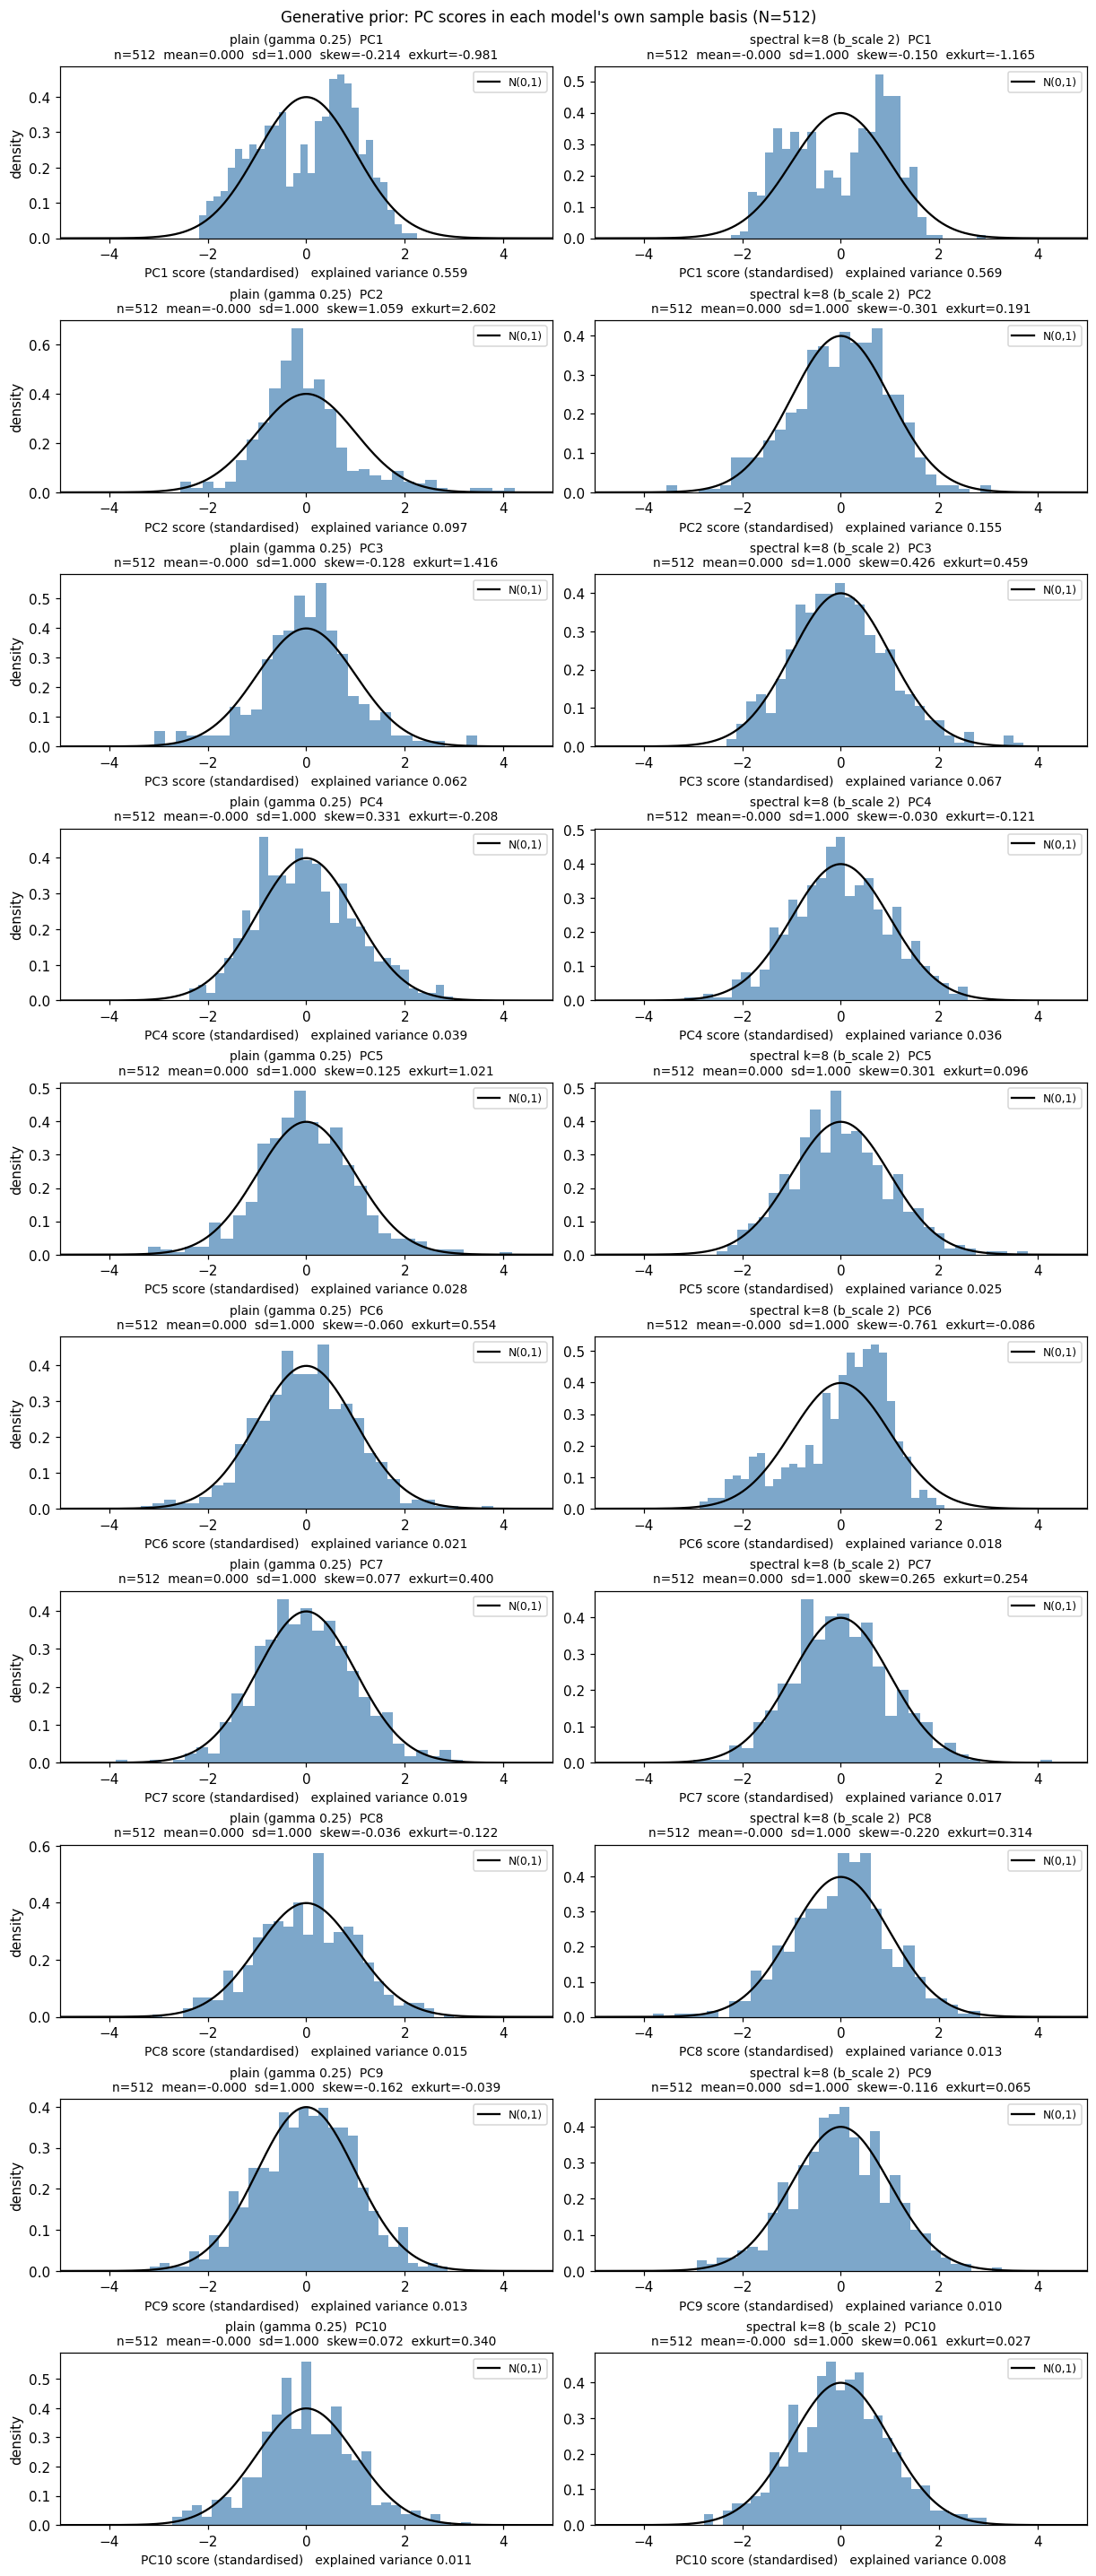

prior     | plain (gamma 0.25):
    PC1  evr 0.559 skew -0.21 exkurt -0.98
    PC2  evr 0.097 skew +1.06 exkurt +2.60
    PC3  evr 0.062 skew -0.13 exkurt +1.42
    PC4  evr 0.039 skew +0.33 exkurt -0.21
    PC5  evr 0.028 skew +0.13 exkurt +1.02
    PC6  evr 0.021 skew -0.06 exkurt +0.55
    PC7  evr 0.019 skew +0.08 exkurt +0.40
    PC8  evr 0.015 skew -0.04 exkurt -0.12
    PC9  evr 0.013 skew -0.16 exkurt -0.04
    PC10 evr 0.011 skew +0.07 exkurt +0.34
prior     | spectral k=8 (b_scale 2):
    PC1  evr 0.569 skew -0.15 exkurt -1.16
    PC2  evr 0.155 skew -0.30 exkurt +0.19
    PC3  evr 0.067 skew +0.43 exkurt +0.46
    PC4  evr 0.036 skew -0.03 exkurt -0.12
    PC5  evr 0.025 skew +0.30 exkurt +0.10
    PC6  evr 0.018 skew -0.76 exkurt -0.09
    PC7  evr 0.017 skew +0.27 exkurt +0.25
    PC8  evr 0.013 skew -0.22 exkurt +0.31
    PC9  evr 0.010 skew -0.12 exkurt +0.06
    PC10 evr 0.008 skew +0.06 exkurt +0.03


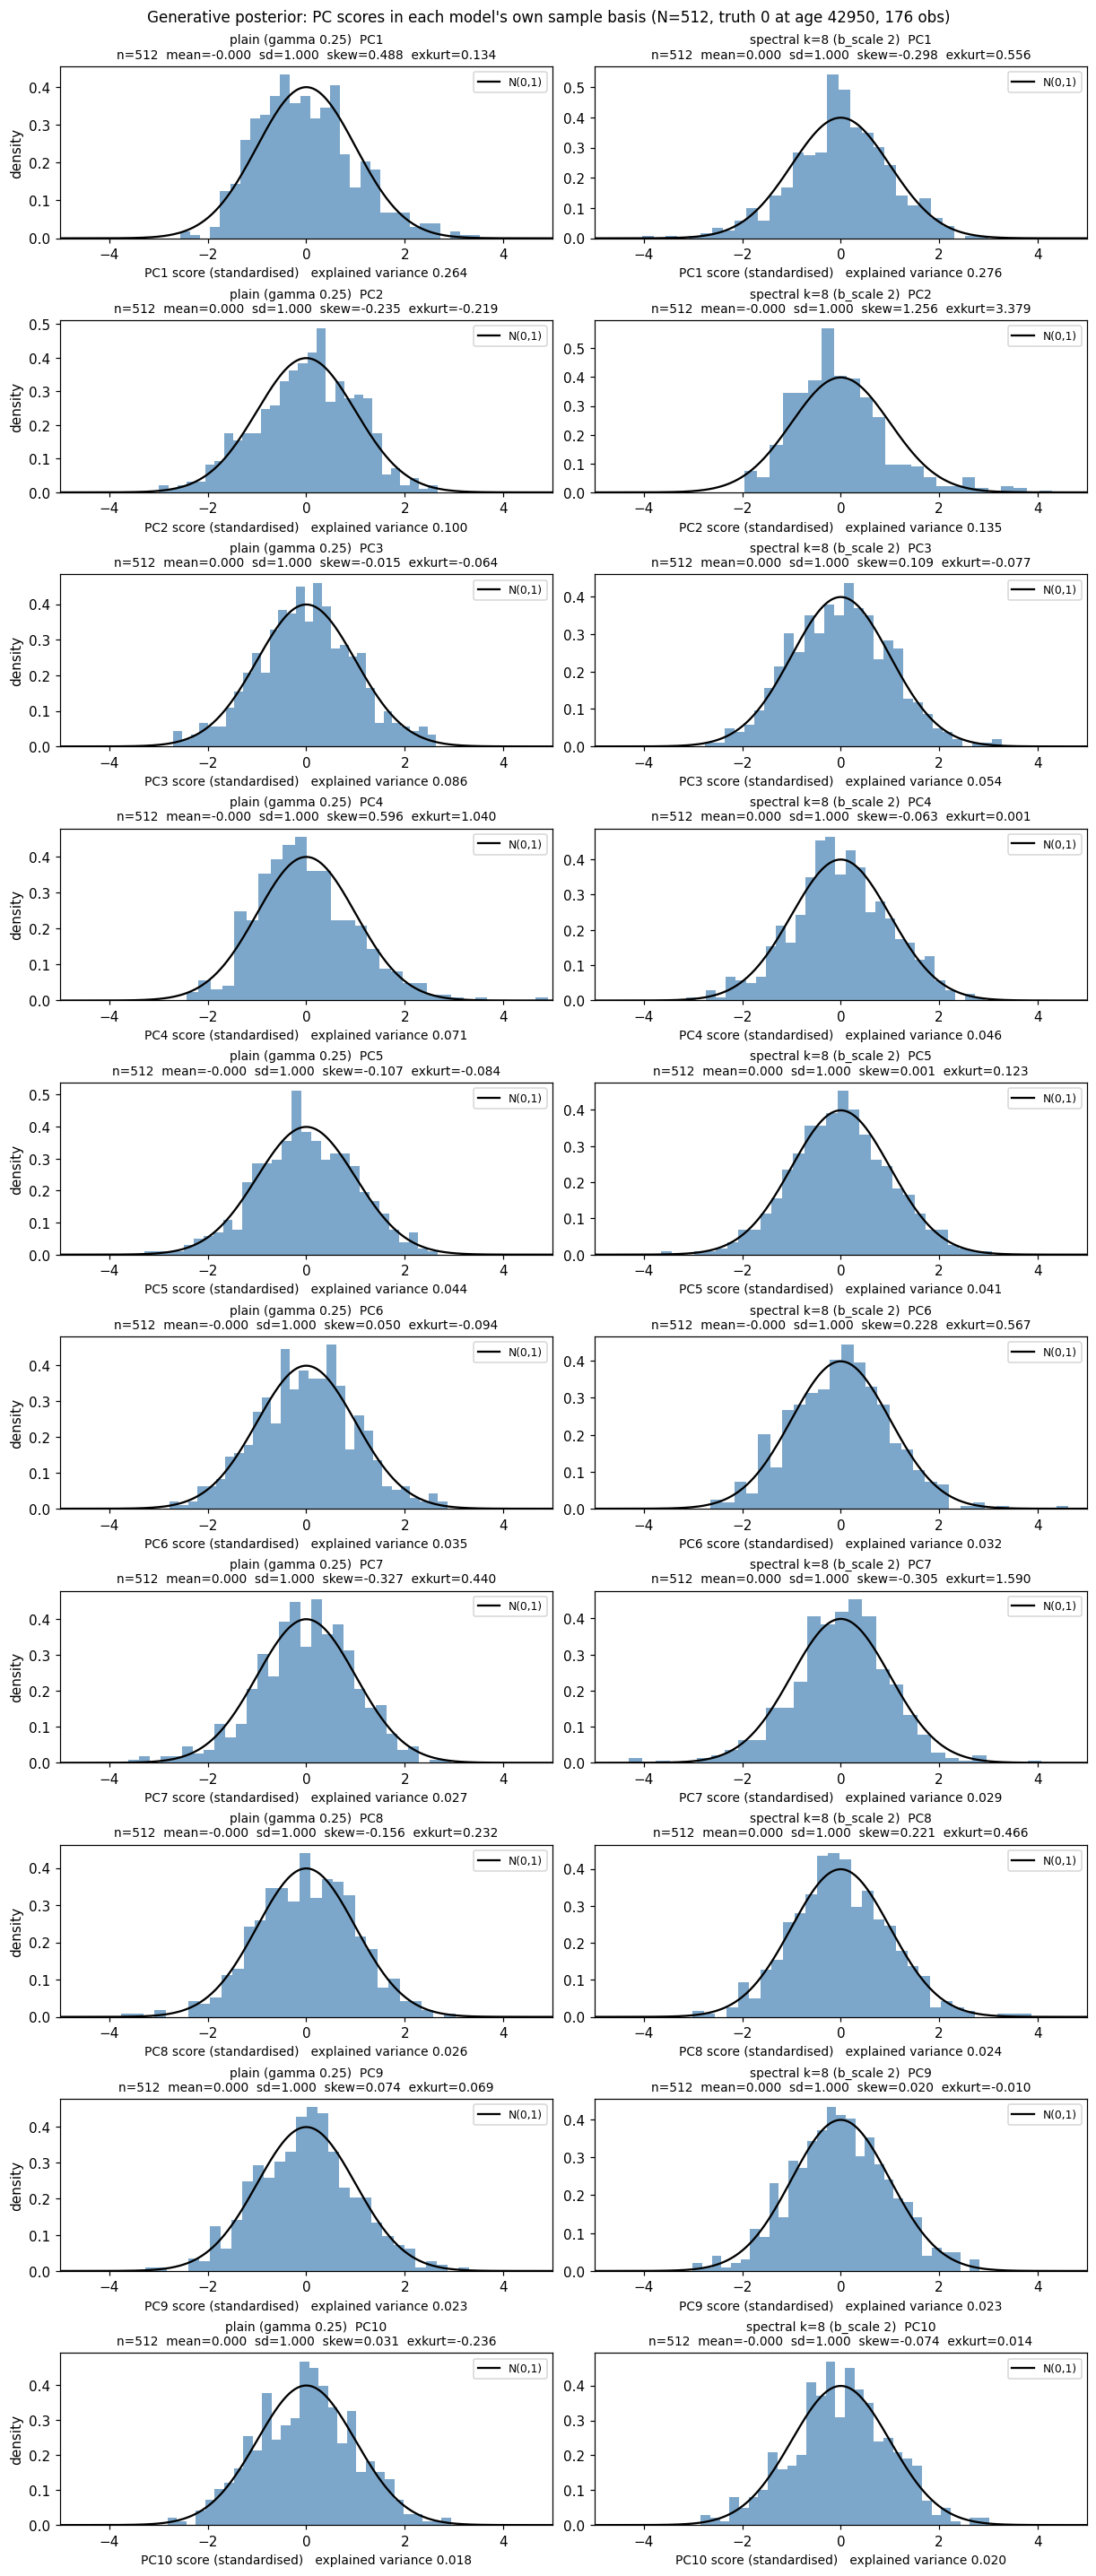

posterior | plain (gamma 0.25):
    PC1  evr 0.264 skew +0.49 exkurt +0.13
    PC2  evr 0.100 skew -0.23 exkurt -0.22
    PC3  evr 0.086 skew -0.01 exkurt -0.06
    PC4  evr 0.071 skew +0.60 exkurt +1.04
    PC5  evr 0.044 skew -0.11 exkurt -0.08
    PC6  evr 0.035 skew +0.05 exkurt -0.09
    PC7  evr 0.027 skew -0.33 exkurt +0.44
    PC8  evr 0.026 skew -0.16 exkurt +0.23
    PC9  evr 0.023 skew +0.07 exkurt +0.07
    PC10 evr 0.018 skew +0.03 exkurt -0.24
posterior | spectral k=8 (b_scale 2):
    PC1  evr 0.276 skew -0.30 exkurt +0.56
    PC2  evr 0.135 skew +1.26 exkurt +3.38
    PC3  evr 0.054 skew +0.11 exkurt -0.08
    PC4  evr 0.046 skew -0.06 exkurt +0.00
    PC5  evr 0.041 skew +0.00 exkurt +0.12
    PC6  evr 0.032 skew +0.23 exkurt +0.57
    PC7  evr 0.029 skew -0.30 exkurt +1.59
    PC8  evr 0.024 skew +0.22 exkurt +0.47
    PC9  evr 0.023 skew +0.02 exkurt -0.01
    PC10 evr 0.020 skew -0.07 exkurt +0.01


In [12]:
import json

from scipy import stats as _st

from paleoreco.assim.experiments import _obs_geometry
from paleoreco.assim.observations import observations_at_age
from paleoreco.eval.projection import orient_pcs, pca_scores, plot_pc_score_distributions

N_PC, N_PC_SAMPLES, PC_TRUTH, PC_BATCH = 10, 512, 0, 64
_name = LANE_PRIOR["ppe"]

# Every generative method that has finished a PPE run, at its own selected operating
# point read from its own config. Keyed on the artefacts rather than on the lane
# toggles, so the figures redraw from a finished run without re-running it.
MODELS, _src = {}, None
for _kind, _dir in (("plain", OUT / "generative"),
                    ("hybrid", OUT / "generative_hybrid"),
                    ("spectral", OUT / "generative_spectral")):
    if not ((_dir / "ppe_config.json").exists() and (_dir / "ppe_analysis.npz").exists()):
        continue
    _sel = json.load(open(_dir / "ppe_config.json"))["selected"]
    _src = _src or _dir
    if _kind == "plain" and _name in SAMPLER:
        MODELS[f"plain (gamma {_sel['b_scale']:g})"] = (SAMPLER[_name], _sel["b_scale"])
    elif _kind == "hybrid" and _name in SAMPLER:
        _cov_w = COV[_name].scaled(_sel["hybrid_amp"])
        MODELS[f"hybrid (amp {_sel['hybrid_amp']:g}, switch {_sel['hybrid_switch']:g}, "
               f"gamma {_sel['b_scale']:g})"] = (
            GuidedSampler(HybridDenoiser(SAMPLER[_name].denoiser, _cov_w,
                                         _sel["hybrid_switch"]),
                          FRAME[_name][1], FRAME[_name][0], _cov_w, **SAMPLER_KW),
            _sel["b_scale"])
    elif _kind == "spectral" and _name in SPECTRAL_SAMPLER:
        MODELS[f"spectral k={SPECTRAL_K} (b_scale {_sel['b_scale']:g})"] = (
            SPECTRAL_SAMPLER[_name], _sel["b_scale"])

if not MODELS:
    print("no generative PPE run with a live sampler; run a lane above first")
else:
    _safe = FRAME[_name][0]
    _z = np.load(_src / "ppe_analysis.npz")

    def draw_prior(sampler, n, seed=0, batch=PC_BATCH):
        """``n`` unconditional draws, batched so peak memory stays bounded."""
        return np.concatenate([sampler.sample_prior(min(batch, n - k), seed=seed + k)
                               for k in range(0, n, batch)])

    # One assimilation shared by every model so the posterior columns are paired:
    # truth PC_TRUTH's held-out test network (the last of its drawn shapes) and the
    # pseudo-observations the lane builds for it.
    _safe_flat = np.broadcast_to(_safe, (len(VARS), *_safe.shape)).ravel()
    _age = int(_z["drawn_ages"][PC_TRUTH, -1])
    _geom = _obs_geometry(observations_at_age(long_ppe, _age), lats, lons, _safe_flat)
    _rng = np.random.default_rng(0)
    _y = (_z["truth_anom"][PC_TRUTH].ravel()[_geom["gather"]]
          + np.mean([_rng.normal(0.0, np.sqrt(_geom["sse"])) for _ in range(5)], axis=0))

    # Each model's PCs are fitted on its own samples, over valid cells and both channels.
    RES_PC = {"prior": {}, "posterior": {}}
    for _label, (_samp, _op) in MODELS.items():
        RES_PC["prior"][_label] = orient_pcs(pca_scores(
            draw_prior(_samp, N_PC_SAMPLES, seed=5000)[:, :, _safe], N_PC))
        RES_PC["posterior"][_label] = orient_pcs(pca_scores(
            _samp.sample_posterior(_geom["gather"], _y, _geom["sse"], _op,
                                   N_PC_SAMPLES, seed=6000)[:, :, _safe], N_PC))

    for _split, _res in RES_PC.items():
        _where = (f", truth {PC_TRUTH} at age {_age}, {len(_geom['gather'])} obs"
                  if _split == "posterior" else "")
        plot_pc_score_distributions(
            _res, n_components=N_PC,
            title=(f"Generative {_split}: PC scores in each model's own sample basis "
                   f"(N={N_PC_SAMPLES}{_where})"),
            save_path=str(FIG / f"pc_marginals_{_split}.png"))
        plt.show()
        for _label, _r in _res.items():
            _sc = _r["scores"]
            print(f"{_split:9s} | {_label}:")
            for k in range(N_PC):
                print(f"    PC{k + 1:<2} evr {_r['explained_variance_ratio'][k]:.3f} "
                      f"skew {_st.skew(_sc[:, k]):+.2f} "
                      f"exkurt {_st.kurtosis(_sc[:, k]):+.2f}")

## Prior vs posterior

For each method that has finished a PPE run: the operating-point tuning curve, the
prior-to-posterior variance reduction, and the pointwise prior/posterior distribution at
a cell near a site and one far from any site.

The tuning curve plots `rrmse_ens`, the surface the operating point was actually
selected on: plain RRMSE carries the finite-ensemble term `mean(post_var) / K`, which
grows with the spread and so tilts the curve toward the tight end.

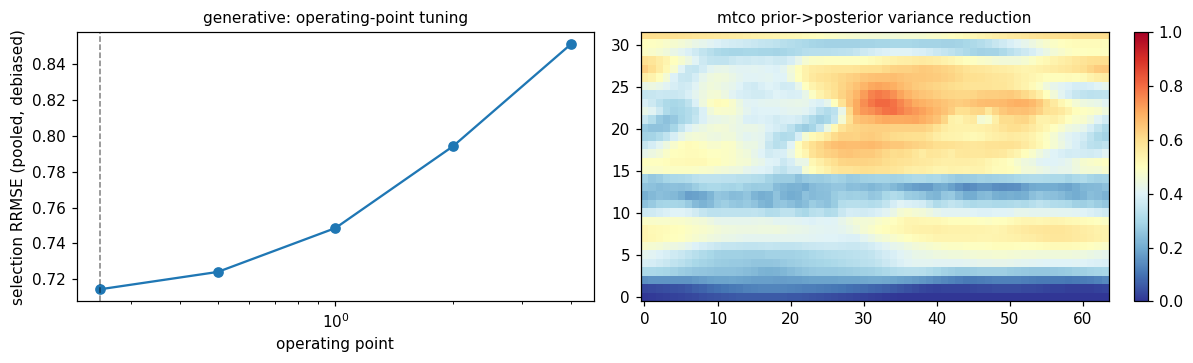

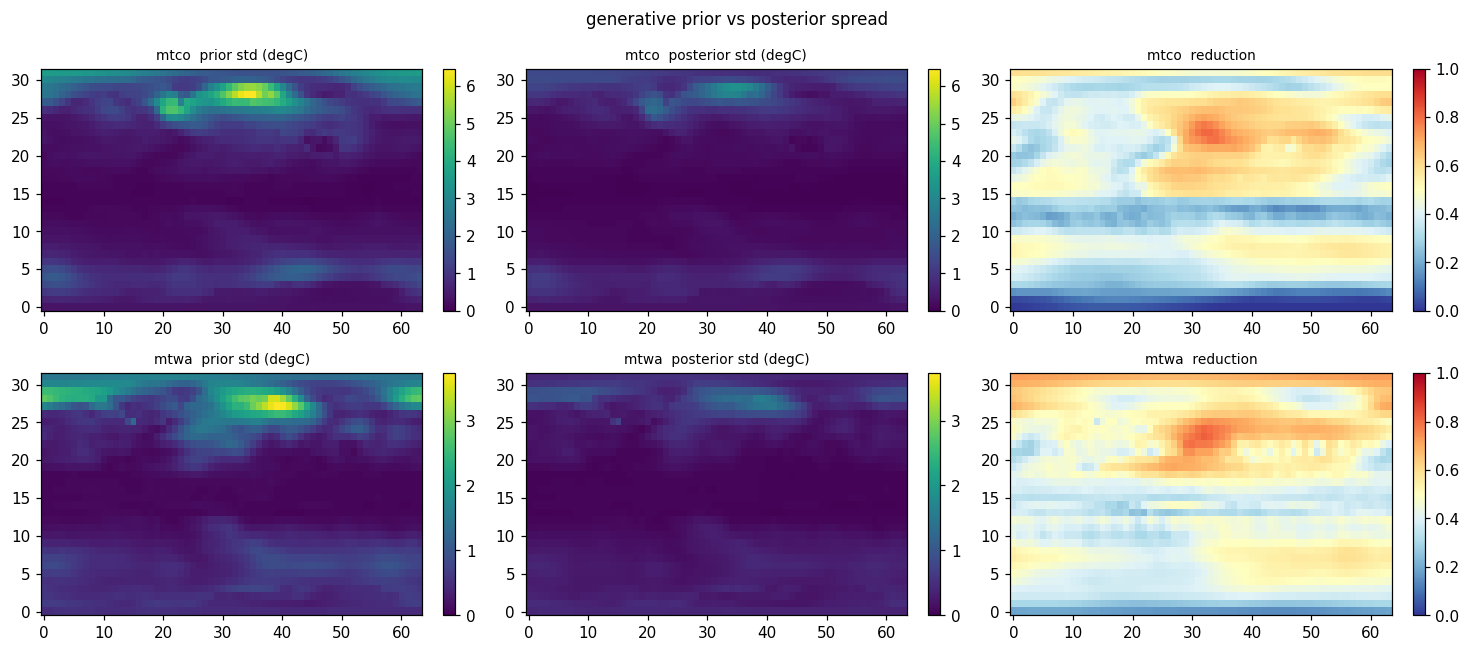

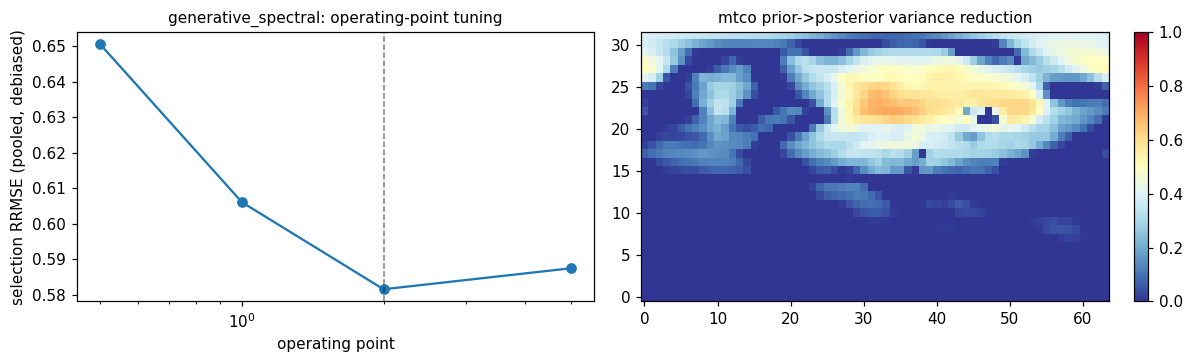

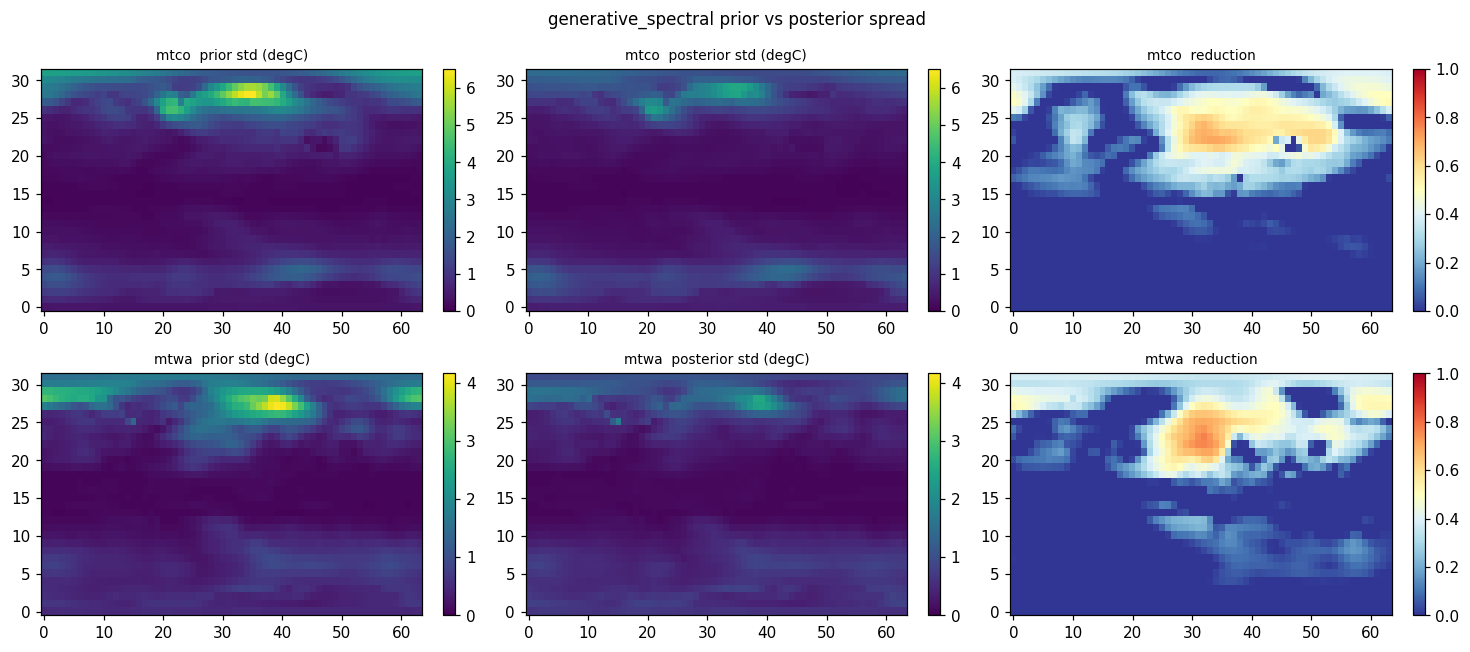

In [13]:
import json

# Tuning curve and prior-to-posterior spread, for whichever methods have a PPE run.
_PPE_DIRS = {"generative": OUT / "generative",
             "generative_hybrid": OUT / "generative_hybrid",
             "generative_spectral": OUT / "generative_spectral"}

for _m, _d in _PPE_DIRS.items():
    if not (_d / "ppe_analysis.npz").exists():
        continue
    _cfg = json.load(open(_d / "ppe_config.json"))["selected"]
    sel = pd.read_csv(_d / "metrics.csv")
    sel = sel[(sel.lane == "ppe") & (sel.split == "selection") & (sel.channel == "pooled")
              & (sel.do_event == "all") & (sel.metric == "rrmse_ens")]
    # The hybrid sweeps two more knobs; show the curve at the selected combination.
    for _c in ("hybrid_amp", "hybrid_switch"):
        if _c in sel.columns and _c in _cfg:
            sel = sel[np.isclose(sel[_c].to_numpy(dtype=float), _cfg[_c])]
    sel = sel.sort_values("b_scale")

    z = np.load(_d / "ppe_analysis.npz")
    safe_ppe = z["safe_valid"]
    fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
    ax[0].plot(sel["b_scale"], sel["value"], "o-")
    ax[0].set_xscale("log")
    ax[0].axvline(float(z["b_scales"][0]), color="k", lw=1, ls="--", alpha=0.5)
    ax[0].set_xlabel("operating point")
    ax[0].set_ylabel("selection RRMSE (pooled, debiased)")
    ax[0].set_title(f"{_m}: operating-point tuning", fontsize=10)

    red = da.uncertainty_reduction(z["prior_ens_var"], z["post_var"][0].mean(axis=0))
    im = ax[1].imshow(np.where(safe_ppe, red[0], np.nan), origin="lower", cmap="RdYlBu_r",
                      vmin=0, vmax=1, aspect="auto")
    ax[1].set_title("mtco prior->posterior variance reduction", fontsize=10)
    fig.colorbar(im, ax=ax[1], fraction=0.046)
    fig.tight_layout()
    fig.savefig(FIG / f"tuning_and_variance_reduction_{_m}.png", bbox_inches="tight")
    plt.show()

    da.plot_prior_posterior_uncertainty(
        z["prior_ens_var"], z["post_var"][0].mean(axis=0), safe_ppe, VARS,
        title=f"{_m} prior vs posterior spread",
        save_path=str(FIG / f"uncertainty_reduction_{_m}.png"))
    plt.show()

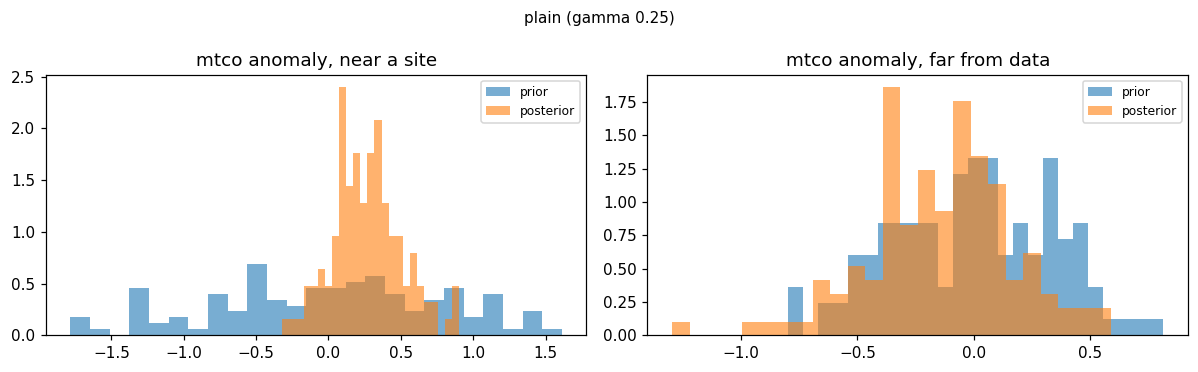

In [14]:
# Pointwise prior vs posterior at a near-site and a far cell (mtco), for one truth,
# using the first model discovered in the PC-marginals cell above.
from paleoreco.assim.experiments import _obs_geometry
from paleoreco.assim.observations import observations_at_age

if not MODELS:
    print("no generative PPE run with a live sampler; run a lane above first")
else:
    _lbl, (_samp, _op) = next(iter(MODELS.items()))
    _safe = FRAME[LANE_PRIOR["ppe"]][0]
    n_cells = len(lats) * len(lons)
    safe_flat = np.broadcast_to(_safe, (len(VARS), *_safe.shape)).ravel()
    z = np.load(_src / "ppe_analysis.npz")
    age0 = int(z["drawn_ages"][0, -1])
    geom = _obs_geometry(observations_at_age(long_ppe, age0), lats, lons, safe_flat)
    y0 = z["truth_anom"][0].ravel()[geom["gather"]]
    post = _samp.sample_posterior(geom["gather"], y0, geom["sse"], _op, 128, seed=1)
    prior = _samp.sample_prior(128, seed=2)

    # Index the mtco channel (cells 0..n_cells-1) at an observed site and at the void.
    near = int(geom["gather"][0]) % n_cells
    far = int(np.argmax(da.nearest_obs_distance(lats, lons, geom["lat"], geom["lon"])))
    fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
    for a, (cell, label) in zip(ax, ((near, "near a site"), (far, "far from data"))):
        a.hist(prior.reshape(128, -1)[:, cell], bins=25, density=True, alpha=0.6,
               label="prior")
        a.hist(post.reshape(128, -1)[:, cell], bins=25, density=True, alpha=0.6,
               label="posterior")
        a.set_title(f"mtco anomaly, {label}"); a.legend(fontsize=8)
    fig.suptitle(_lbl, fontsize=10)
    fig.tight_layout()
    fig.savefig(FIG / "pointwise_prior_posterior.png", bbox_inches="tight")
    plt.show()

## Reading

The cross-method comparison against 3DVar (skill, calibration, prior-to-posterior,
gallery) lives in `09_da_comparison`, which discovers `outputs/da/generative/`,
`outputs/da/generative_hybrid/` and `outputs/da/generative_spectral/` automatically.

What to read first depends on the method. For the two pixel-space priors, the generated
per-cell std map should track the real one in amplitude as well as pattern, since the
scale field carries it rather than the network. For the spectral prior the covariance is
imposed rather than learned, so the question is instead whether the PC marginals above
show genuine bimodality in the leading components and whether it survives into the
posterior - and then whether that translates into skill in notebook 09, which is the
only place the claim is actually settled.